<a href="https://colab.research.google.com/github/mullinskatie7-source/katherine-mullins.github.io/blob/main/Katherine_Mullins_PumpSizingForLakeIrrigrationSystem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Markdown
# Pump Sizing for a Lakeside Irrigation System

**Engineer:** Katherine Mullins

**Completion Date:** 07/02/2026

**Class:** EGN3214

**Assignment #:** 7

**Tool Used:** Colab / Python

## Problem Description

A pump must move water from a lake to a storage tank located 40 ft above the lake surface. The desired fill rate is 500 L/min. Water flows through 250 m of 3 in inside-diameter PVC pipe. The analysis must determine the total dynamic head required by the system and determine whether a real pump can meet the required flow and head.

The system is initially modeled using static lift and straight-pipe friction loss. Minor losses from fittings, intake screens, valves, and elbows are set to zero for the preliminary calculation because the assignment does not provide fitting details. These losses can be added later if needed.

## Methodology

The Swamee-Jain equation was selected as the main friction-factor method because it is explicit and easy to calculate in Python. The Colebrook equation was also solved using SciPy’s brentq() function as a verification step. The two friction-factor values should be very close, which supports using Swamee-Jain for the system-curve calculations.

The Colebrook equation and the Swamee-Jain equation were compared because both estimate the Darcy friction factor for turbulent flow. The Colebrook equation is more computationally difficult because the friction factor appears on both sides of the equation and must be solved numerically. The Swamee-Jain equation provides an explicit approximation that can be calculated directly. Colebrook was solved with SciPy’s brentq() root-finding function to verify the Swamee-Jain result.

The two calculated friction factors were very close, so the Swamee-Jain equation was selected for the system-curve calculations due to its simpler implementation and suitability for repeated calculations.


Converted Inputs
----------------------------------------
Static lift: 12.192 m
Target flow: 0.008333 m^3/s
Target flow: 132.09 GPM
Pipe inside diameter: 0.0762 m
Pipe length: 250.0 m
Flow Conditions
----------------------------------------
Pipe area: 0.004560 m^2
Water velocity: 1.827 m/s
Reynolds number: 138,715
Relative roughness: 0.00001969
Flow regime: Turbulent
Friction Factor Comparison
----------------------------------------
Swamee-Jain friction factor: 0.016847
Colebrook friction factor:   0.016948
Percent difference:          0.598%
Head Calculation
----------------------------------------
Static lift: 12.192 m
Pipe friction loss: 9.407 m
Total dynamic head: 21.599 m
Total dynamic head: 70.86 ft
Hydraulic Power
----------------------------------------
Hydraulic power: 1762.5 W
Hydraulic power: 1.763 kW
Hydraulic power: 2.364 hp


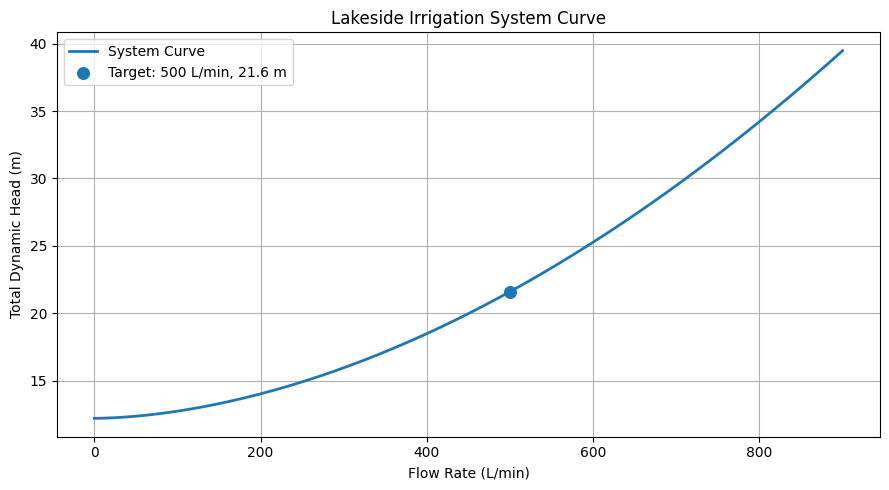

In [3]:
# Step 2: Import required modules and define constants
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# Step 3: Conversion Functions and Inputs

def feet_to_meters(feet):
    return feet * 0.3048

def inches_to_meters(inches):
    return inches * 0.0254

def liters_per_minute_to_m3_per_s(liters_per_minute):
    return liters_per_minute / 1000 / 60

def liters_per_minute_to_gpm(liters_per_minute):
    return liters_per_minute * 0.264172052

def meters_to_feet(meters):
    return meters / 0.3048

def watts_to_kw(watts):
    return watts / 1000

def watts_to_hp(watts):
    return watts / 745.699872


# Given assignment inputs
STATIC_LIFT_FT = 40.0
FLOW_TARGET_LPM = 500.0
PIPE_ID_IN = 3.0
PIPE_LENGTH_M = 250.0

# Water properties at 20 degrees C
RHO_WATER = 998.2
MU_WATER = 1.002e-3

# PVC pipe roughness
PVC_ROUGHNESS_M = 1.5e-6

G = 9.81

# Initial assumption: no fitting or valve losses
MINOR_LOSS_K = 0.0

# Step 4: Convert Inputs
static_lift_m = feet_to_meters(STATIC_LIFT_FT)
flow_target_m3_s = liters_per_minute_to_m3_per_s(FLOW_TARGET_LPM)
pipe_id_m = inches_to_meters(PIPE_ID_IN)

print("Converted Inputs")
print("-" * 40)
print(f"Static lift: {static_lift_m:.3f} m")
print(f"Target flow: {flow_target_m3_s:.6f} m^3/s")
print(f"Target flow: {liters_per_minute_to_gpm(FLOW_TARGET_LPM):.2f} GPM")
print(f"Pipe inside diameter: {pipe_id_m:.4f} m")
print(f"Pipe length: {PIPE_LENGTH_M:.1f} m")

# Step 5: Velocity and Reynolds Number
pipe_area_m2 = np.pi * pipe_id_m**2 / 4
velocity_m_s = flow_target_m3_s / pipe_area_m2

reynolds_number = (
    RHO_WATER * velocity_m_s * pipe_id_m / MU_WATER
)

relative_roughness = PVC_ROUGHNESS_M / pipe_id_m

print("Flow Conditions")
print("-" * 40)
print(f"Pipe area: {pipe_area_m2:.6f} m^2")
print(f"Water velocity: {velocity_m_s:.3f} m/s")
print(f"Reynolds number: {reynolds_number:,.0f}")
print(f"Relative roughness: {relative_roughness:.8f}")

if reynolds_number < 2300:
    print("Flow regime: Laminar")
else:
    print("Flow regime: Turbulent")
# Step 6: Swamee-Jain and Colebrook Comparison

def swamee_jain_friction_factor(reynolds, relative_roughness):
    return 0.25 / (
        np.log10(
            (relative_roughness / 3.7)
            + (5.74 / reynolds**0.9)
        )
    )**2


def colebrook_equation(friction_factor, reynolds, relative_roughness):
    return (
        1 / np.sqrt(friction_factor)
        + 2 * np.log10(
            (relative_roughness / 3.7)
            + (2.51 / (reynolds * np.sqrt(friction_factor)))
        )
    )


f_swamee_jain = swamee_jain_friction_factor(
    reynolds_number,
    relative_roughness
)

f_colebrook = brentq(
    colebrook_equation,
    0.008,
    0.08,
    args=(reynolds_number, relative_roughness)
)

percent_difference = (
    abs(f_swamee_jain - f_colebrook) / f_colebrook * 100
)

print("Friction Factor Comparison")
print("-" * 40)
print(f"Swamee-Jain friction factor: {f_swamee_jain:.6f}")
print(f"Colebrook friction factor:   {f_colebrook:.6f}")
print(f"Percent difference:          {percent_difference:.3f}%")

# Step 7: Total Dynamic Head

def calculate_system_head(flow_m3_s):
    if flow_m3_s <= 0:
        return static_lift_m

    area_m2 = np.pi * pipe_id_m**2 / 4
    velocity = flow_m3_s / area_m2

    reynolds = RHO_WATER * velocity * pipe_id_m / MU_WATER
    rel_roughness = PVC_ROUGHNESS_M / pipe_id_m

    if reynolds < 2300:
        friction_factor = 64 / reynolds
    else:
        friction_factor = swamee_jain_friction_factor(
            reynolds,
            rel_roughness
        )

    major_head_loss_m = (
        friction_factor
        * (PIPE_LENGTH_M / pipe_id_m)
        * (velocity**2 / (2 * G))
    )

    minor_head_loss_m = MINOR_LOSS_K * (velocity**2 / (2 * G))

    return static_lift_m + major_head_loss_m + minor_head_loss_m


friction_head_m = (
    f_swamee_jain
    * (PIPE_LENGTH_M / pipe_id_m)
    * (velocity_m_s**2 / (2 * G))
)

total_dynamic_head_m = calculate_system_head(flow_target_m3_s)

print("Head Calculation")
print("-" * 40)
print(f"Static lift: {static_lift_m:.3f} m")
print(f"Pipe friction loss: {friction_head_m:.3f} m")
print(f"Total dynamic head: {total_dynamic_head_m:.3f} m")
print(f"Total dynamic head: {meters_to_feet(total_dynamic_head_m):.2f} ft")

# Step 8: Hydraulic Power

hydraulic_power_w = (
    RHO_WATER
    * G
    * flow_target_m3_s
    * total_dynamic_head_m
)

print("Hydraulic Power")
print("-" * 40)
print(f"Hydraulic power: {hydraulic_power_w:.1f} W")
print(f"Hydraulic power: {watts_to_kw(hydraulic_power_w):.3f} kW")
print(f"Hydraulic power: {watts_to_hp(hydraulic_power_w):.3f} hp")

# Step 9: System Curve Plot

flow_lpm_values = np.linspace(0, 900, 200)

flow_m3_s_values = np.array([
    liters_per_minute_to_m3_per_s(flow)
    for flow in flow_lpm_values
])

system_head_values_m = np.array([
    calculate_system_head(flow)
    for flow in flow_m3_s_values
])

plt.figure(figsize=(9, 5))

plt.plot(
    flow_lpm_values,
    system_head_values_m,
    linewidth=2,
    label="System Curve"
)

plt.scatter(
    FLOW_TARGET_LPM,
    total_dynamic_head_m,
    s=70,
    label=f"Target: {FLOW_TARGET_LPM:.0f} L/min, {total_dynamic_head_m:.1f} m"
)

plt.xlabel("Flow Rate (L/min)")
plt.ylabel("Total Dynamic Head (m)")
plt.title("Lakeside Irrigation System Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()